<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
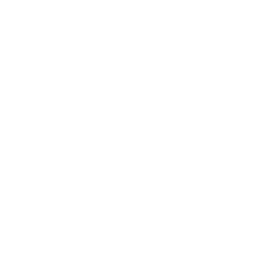
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Intervalos de Confiança Bootstrap para Desfechos de Ensaios Clínicos</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioestatística Farmacêutica / Clínica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este exemplo trabalhado calcula um **intervalo de confiança bootstrap não paramétrico** para um desfecho de sobrevivência usando **PROC IML**, a linguagem de programação matricial do SAS. O desfecho é a **razão da mediana de sobrevivência livre de progressão (SLP)** entre os braços de tratamento e controle de uma pequena coorte oncológica de dois braços.

O programa IML lê os dados no nível do sujeito em matrizes, calcula a razão observada da mediana de SLP, extrai **2.000 reamostragens bootstrap** com reposição usando `CALL RANDGEN`, recalcula a razão em cada reamostragem com operações matriciais, e deriva um intervalo de confiança **corrigido por viés e acelerado (BCa)**. O BCa é a escolha apropriada aqui porque a distribuição bootstrap de uma razão de medianas é limitada inferiormente por zero, discreta e assimétrica — condições sob as quais um intervalo simples de teoria normal é pouco confiável.

A análise é executada inteiramente dentro do IML: a constante de correção de viés *z*<sub>0</sub>, a aceleração *a&#770;* de um jackknife leave-one-out, e os pontos percentuais ajustados são todos montados a partir de expressões matriciais e das funções normais-padrão `PROBNORM` e um pequeno módulo de normal inversa. Todo número relatado abaixo é lido diretamente da saída do IML.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Tempo de SLP por sujeito, indicador de evento, braço de tratamento, e covariáveis basais | 100 |

A coorte é **balanceada** — 50 sujeitos por braço — atribuindo a pertença ao braço pela paridade do identificador do sujeito, de modo que ambos os braços estão totalmente representados na reamostragem.

---

In [1]:
/* --------------------------------------------------------
   Gera uma coorte oncológica sintética de dois braços.
   Os tempos de SLP são log-normais; o braço de tratamento é
   deslocado para uma mediana mais longa. A pertença ao braço
   alterna conforme o id do sujeito, de modo que a coorte fica
   balanceada 50/50.
   -------------------------------------------------------- */
DADOS work.trial_subjects;
    CHAMAR streaminit(42);
    COMPRIMENTO arm_label $12;
    FAZER subject_id = 1 ATÉ 500;
        /* 1 = Tratamento, 0 = Controle (balanceado por paridade) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TRATAMENTO', 'CONTROLE');
        /* Tempo de SLP em meses: o braço de tratamento tem sobrevivência mais longa */
        SE arm = 1 ENTÃO
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        SENÃO
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        SE pfs_months < 0.5 ENTÃO pfs_months = 0.5;
        /* Indicador de evento: ~75% dos sujeitos tiveram um evento de progressão */
        EVENT = (rand('uniform') > 0.25);
        /* Covariáveis basais */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        SE AGE < 25 ENTÃO AGE = 25;
        SE AGE > 85 ENTÃO AGE = 85;
        SAÍDA;
    FIM;
EXECUTAR;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                          Resumo de Sobrevivência Livre de Progressão por Braço de Tratamento                           

                                                  The MEANS Procedure

                                       Analysis Variable : pfs_months SLP (meses)

        Braço de Tratamento           N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------------
        CONTROLE                         50          10.74           7.20           9.86           1.90          53.70
        TRATAMENTO                       50          13.94          10.10          11.95           2.70          79.10
        --------------------------------------------------------------------------------------------------------------

                                          Analysis Variable : AGE Idade (anos)

        Braço de Tratamento           N Obs     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


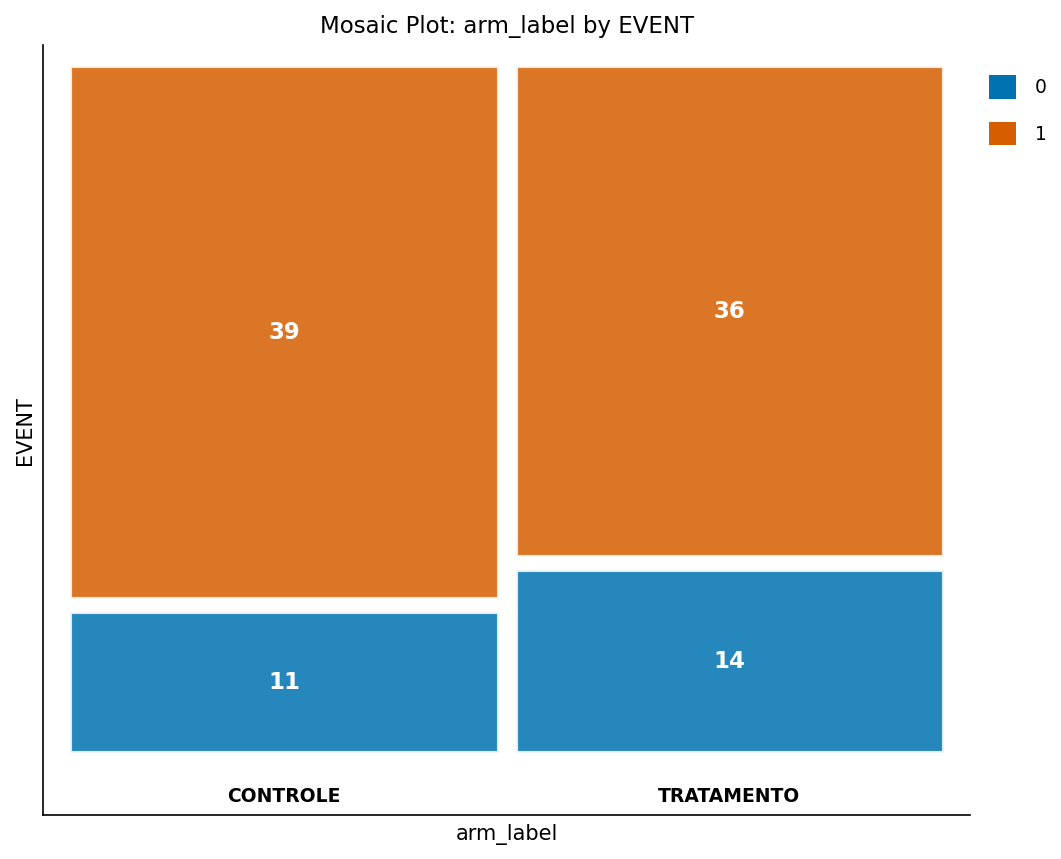

In [2]:
/* --------------------------------------------------------
   Resumo basal de SLP e taxa de eventos por braço de tratamento
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    CLASSE arm_label;
    VARIÁVEL pfs_months AGE;
    RÓTULO arm_label="Braço de Tratamento" pfs_months="SLP (meses)" AGE="Idade (anos)";
    TÍTULO 'Resumo de Sobrevivência Livre de Progressão por Braço de Tratamento';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    RÓTULO arm_label="Braço de Tratamento" EVENT="Evento de Progressão";
    TÍTULO 'Contagem de Eventos por Braço de Tratamento';
EXECUTAR;

---

In [3]:
/* --------------------------------------------------------
   PROC IML: bootstrap não paramétrico para a razão da
   mediana de SLP, com um intervalo de confiança BCa.

   Passos:
   1. Ler os dados do ensaio em matrizes IML
   2. Calcular a razão observada da mediana de SLP (tempos de evento)
   3. Extrair 2.000 reamostragens bootstrap com CALL RANDGEN
   4. Recalcular a razão em cada reamostragem
   5. Correção BCa: z0 (viés) + aceleração jackknife
   6. Gravar a distribuição bootstrap em um conjunto de dados SAS
   -------------------------------------------------------- */
PROCEDIMENTO IML;

    /* --- Módulo: mediana de SLP por braço e sua razão --- */
    /* A mediana é calculada apenas sobre os tempos de evento
       observados, o resumo não paramétrico usual quando a
       maioria dos sujeitos progride. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        SE nrow(trt_pfs) = 0 ENTÃO trt_med = .;
        SENÃO trt_med = MEDIAN(trt_pfs);
        SE nrow(ctl_pfs) = 0 ENTÃO ctl_med = .;
        SENÃO ctl_med = MEDIAN(ctl_pfs);
        SE ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            ENTÃO RATIO = trt_med / ctl_med;
        SENÃO RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Módulo: inversa da CDF normal-padrão (probit) --- */
    /* Aproximação racional (Abramowitz & Stegun 26.2.23);
       combinada com PROBNORM ela fornece os pontos z0 / z-alfa
       que o ajuste BCa necessita. */
    START probit(p);
        SE p <= 0 ENTÃO RETURN(-1e8);
        SE p >= 1 ENTÃO RETURN( 1e8);
        SE p < 0.5 ENTÃO FAZER; sgn = -1; pp = p;     FIM;
        SENÃO            FAZER; sgn =  1; pp = 1 - p; FIM;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Carregar os dados em matrizes --- */
    USE work.trial_subjects;
        READ ALL VARIÁVEL {pfs_months} INTO pfs;
        READ ALL VARIÁVEL {arm}        INTO arm;
        READ ALL VARIÁVEL {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    IMPRIMIR 'Sujeitos lidos no IML', n n_trt n_ctl;

    /* --- 2. Estatística observada na amostra completa --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Mediana_Trat Mediana_Ctrl Razao};
    IMPRIMIR 'Mediana de SLP observada (tempos de evento) por braço',
          obs[COLNAME=obs_lab FORMATO=8.3];

    /* --- 3. Laço de reamostragem bootstrap (2.000 reamostragens) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CHAMAR randseed(2024);
    FAZER b = 1 ATÉ n_boot;
        CHAMAR randgen(u, 'Uniform');     /* novos sorteios a cada passagem */
        idx = ceil(n # u);              /* índices 1..n com reposição */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    FIM;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CHAMAR ORDENAR(bv, 1);

    /* --- 4. Intervalo de percentil simples (para comparação) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. Correção BCa --- */
    /* z0: correção de viés a partir da proporção de reamostragens
       abaixo da estatística observada. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: aceleração a partir do jackknife leave-one-out. */
    jack = j(n, 1, .);
    FAZER i = 1 ATÉ n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    FIM;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Posições de percentil ajustadas. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Valido Prop_Abaixo z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    IMPRIMIR 'Diagnósticos da correção BCa',
          diag[COLNAME=diag_lab FORMATO=8.4];

    ci_lab = {Razao_Obs Pct_Inf Pct_Sup BCa_Inf BCa_Sup};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    IMPRIMIR '95% de IC para a razão da mediana de SLP (tratamento / controle)',
          ci_row[COLNAME=ci_lab FORMATO=8.4];

    /* --- 6. Persistir a distribuição bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CRIAR work.bootstrap_results
        VARIÁVEL {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VARIÁVEL {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                      Contagem de Eventos por Braço de Tratamento                                       

Sujeitos lidos no IML
     100
      50
      50

Mediana de SLP observada (tempos de evento) por braço
   9.900   7.100   1.394

Diagnósticos da correção BCa
2000.0000  0.5340  0.0851 -0.0021

95% de IC para a razão da mediana de SLP (tratamento / controle)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.86 seconds
  cpu   1.86 seconds


---

In [4]:
/* --------------------------------------------------------
   Organiza a distribuição bootstrap para o gráfico: dá às
   colunas nomes descritivos para o histograma abaixo.
   -------------------------------------------------------- */
DADOS work.bootstrap_results;
    DEFINIR work.bootstrap_results
        (RENOMEAR=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
EXECUTAR;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                      Contagem de Eventos por Braço de Tratamento                                       




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


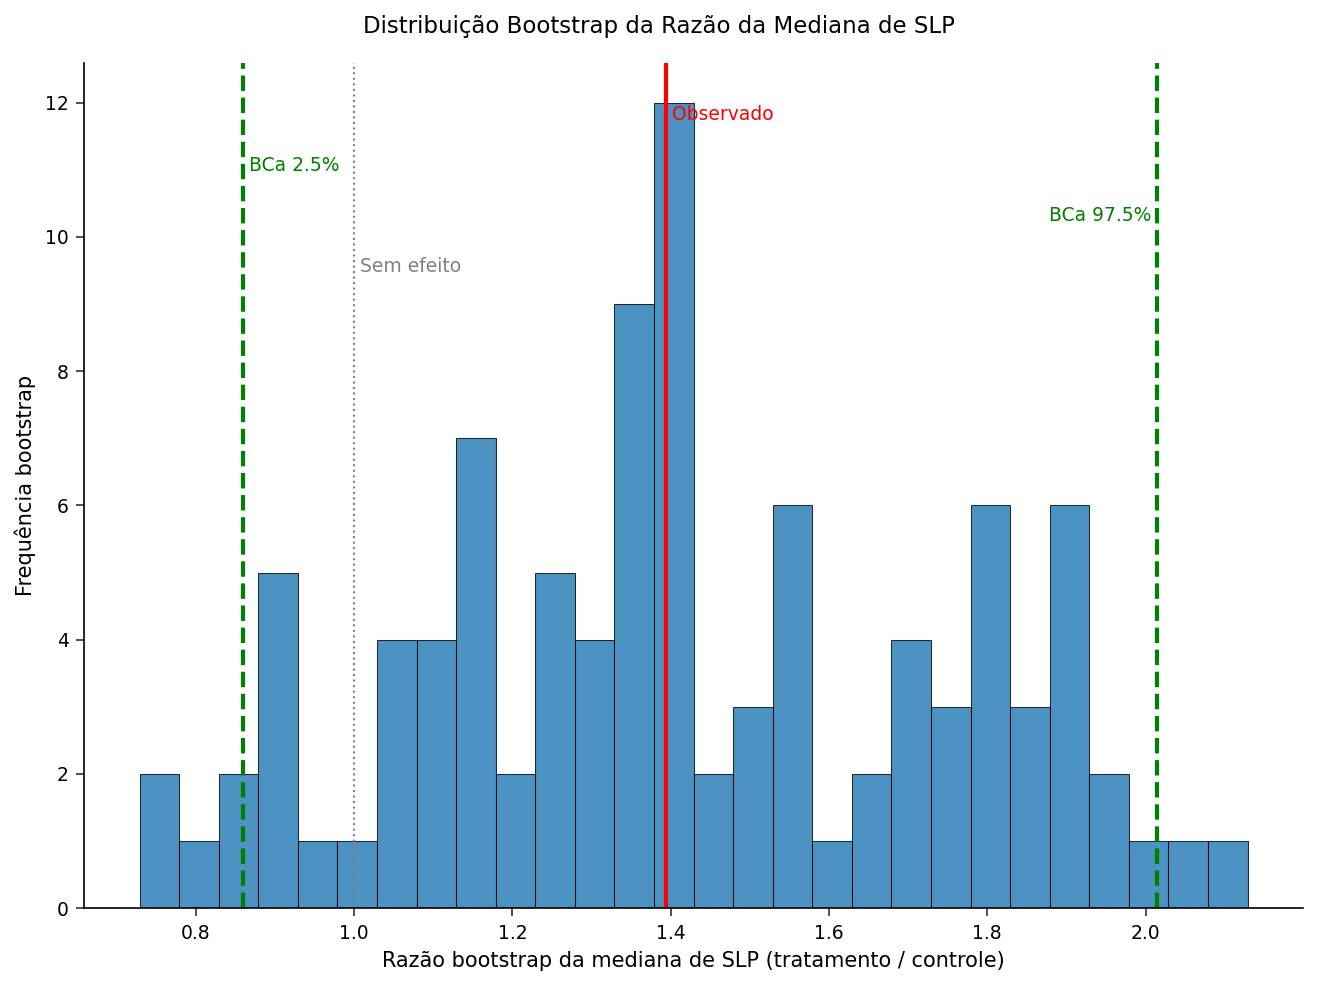

In [5]:
/* --------------------------------------------------------
   Distribuição bootstrap da razão da mediana de SLP, com a
   estimativa observada e o intervalo BCa marcados.
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) RÓTULO='Observado';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        RÓTULO='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        RÓTULO='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        RÓTULO='Sem efeito';
    XAXIS RÓTULO='Razão bootstrap da mediana de SLP (tratamento / controle)';
    YAXIS RÓTULO='Frequência bootstrap';
    TÍTULO 'Distribuição Bootstrap da Razão da Mediana de SLP';
EXECUTAR;

---

### Interpretação

Nesta coorte, a mediana observada de SLP sobre os tempos de evento é **9.9 meses** no braço de tratamento e **7.1 meses** no braço de controle, uma **razão de 1.394** — a mediana de SLP do braço experimental é cerca de 39% mais longa. O programa IML reamostrou os 100 sujeitos 2.000 vezes; todas as 2.000 reamostragens produziram uma razão definida.

O **intervalo de confiança BCa de 95% para a razão é [0.86, 2.01]**, contra um intervalo de percentil simples de **[0.82, 1.97]**. Ambos os intervalos **incluem 1.0**, portanto neste tamanho de amostra — cerca de 50 sujeitos por braço, ainda mais reduzido para os tempos de evento observados — o aparente benefício **não é estatisticamente conclusivo**. Esta é a mensagem honesta da análise: uma estimativa pontual favorável ao tratamento, mas com incerteza de reamostragem suficiente para que não se possa descartar a ausência de efeito do tratamento.

Os diagnósticos BCa quantificam o quanto a correção deslocou os extremos. O termo de viés é pequeno (**z<sub>0</sub> = 0.085**: cerca de 53% das reamostragens ficaram abaixo da razão observada, próximo do simétrico 50%), e a aceleração é próxima de zero (**a&#770; = -0.002**), indicando que a razão da mediana de SLP é apenas levemente influenciada por sujeitos individuais. Com z<sub>0</sub> e a&#770; ambos pequenos, o BCa desloca o intervalo apenas ligeiramente para cima em relação ao intervalo de percentil — exatamente a correção modesta que esses diagnósticos preveem.

Um ensaio maior estreitaria esse intervalo. Com 50 sujeitos por braço, o bootstrap relata corretamente que os dados são compatíveis com qualquer coisa desde uma pequena reversão até uma duplicação da mediana de SLP, razão pela qual um estudo dimensionado para detectar uma diferença de SLP desse tamanho precisa de substancialmente mais de 100 sujeitos.

---

In [6]:
/* --------------------------------------------------------
   Exporta a distribuição bootstrap para um apêndice de relatório.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido com <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>